# Training a Transofmer based model with pl lighting

In [95]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
from prodigyopt import Prodigy # proddigy optimizer from https://github.com/konstmish/prodigy?tab=readme-ov-file
import lightning.pytorch as pl
from torch.utils.data import DataLoader
import tqdm
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
import time

# remove all warnings
import warnings
warnings.filterwarnings("ignore")
from dataset import RobotPathDataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [96]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

In [97]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()

In [98]:
epochs = 1000
representiation_dim = 64
EXPERIMENT_NAME='u-net new training'

In [108]:

CONFIG = {
    # Model configuration
    'representation_dim': representiation_dim, # Dimension of the representation
    'model_type': 'u_net', # 'transformer', 'u-net'
    # specific model configuration
    'transfomer':{
        'num_heads':4,
        'use_sin_activation':True, 
        'num_layers': 4,
        'dim_feed_forward_ratio':2,
        'use_adaln': False,
    },
    # U-Net Architecture
    'u_net' :{
        'dim_mults': (1, 2, 4, 8),  # Dimension multipliers for hidden layers of the model
        'attention': False,
    },
    'multi_loss_warm_up_steps': 1000,
    'predict_noise': True, # Predict the noise added during diffusion or predict the x_t-1 
    # Embedder configuration
    'embeder_num_of_hidden_layers' : 1,
    'encoder_conditional_dim': representiation_dim//2,
    
    # Encoders
    # world encoder
    'world_encoder':{
        'end2end_train':False,
        'ckpt_path': r'pretrained_models/64-encoder.ckpt',
    },
    # Hyperparameters for training
    'batch_size': 8,
    'num_epochs': epochs,
    'ema': EMA(beta=0.99), # Exponential moving average for the model weights
        # Optimizer configuration
        'optimizer': Prodigy,
        'optimizer_kwargs': {
            'lr': 1., # ! ONLY FOR PRODIGY OPTIMIZER
            'weight_decay': 0.01, 
            'safeguard_warmup':True,
            'use_bias_correction':True,
            'betas': (0.9, 0.99),
            },
        # 'optimizer': torch.optim.Adam,
        # 'optimizer_kwargs': {
        #     'lr': 1e-5,
        #     'weight_decay': 0.01,
        #     'betas': (0.9, 0.999),
        # },
        # Scheduler configuration
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,
        'scheduler_kwargs': {
            # 'gamma': 0.999,
            'T_max': 10, # Total number of iterations
            # 'safeguard_warmup':True,
        },
        # 'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau,
        # 'scheduler_kwargs': {
        #     'factor': 0.5,
        #     'patience': 10,
        #     'threshold': 1e-3,
        #     'min_lr': 1e-6,
        #     'verbose': True,
        # },
        # normal scheduler
        # 'scheduler': torch.optim.lr_scheduler.StepLR,
        # 'scheduler_kwargs': {
        #     'step_size': 10,
        #     'gamma': 0.1,
        # },
    
    'loss_weights':{
        'MSE': 1, # best for overfitting 1 sample is 0.004
        'ObstacleFreePathLoss': 0.0, # bround truth avg prefromance is 0.045
        'GraphBasedConsistencyLoss': 0, # ground truth avg prefromance is 0.00031
    },
    # Hyperparameters for diffusion process
    'noise_steps': 256,
    'cfg_scale': 3,
    # VERY IMPORTANT HYPERPARAMETERS FOR DIFFUSION INTERACTS AGGRESSIVLEY WITH NUMBER OF STEPS
    'diffusion_scheduler': 'linear', # 'linear', 'cosine' # Cosine can't have more than
    'beta_end': 3e-4, # CAREFULL: if cosine scheulders this is the clip beta allowed
    'beta_start': 3e-7, # CAREFULL: if cosine scheulders this is the min start beta used called S in the paper

    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    
    # Dataset specific configuration
    'n_paths_per_world': 1000,
    'n_worlds': 1,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
    'single_world_dataset':True,

    # logging 
    'visualize_every_n_steps': 1,
    'stats_every_n_steps': 100,
}

In [100]:
if CONFIG['single_world_dataset']:
    CONFIG['n_worlds'] = 1
    file = 'data/SingleSphere02_one-world.db'
else:
    file = 'data/SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'], single_world_dataset=CONFIG['single_world_dataset'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples consisting of n worlds {len(np.unique(dataset.worlds_indx))}')
indx_sample = 0
sample = dataset[indx_sample];

data shape: torch.Size([1000, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:1, samples: 1000
 sample shape torch.Size([64, 2]) with 1000 samples consisting of n worlds 1


In [101]:
import torch.utils
import torch.utils.data


class RobotPathDataModule(pl.LightningDataModule):
    def __init__(self, dataset, batch_size: int = 64, val_dataset_ratio=0.00):
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.val_dataset_ratio = val_dataset_ratio

    def setup(self, stage=None):
        # Assign train/val datasets for use in dataloaders
        if stage == 'fit' or stage is None:
            self.train_dataset, self.val_dataset = self._split_train_val(self.dataset)

        # Assign test dataset for use in dataloader(s)
        if stage == 'test' or stage is None:
            assert NotImplementedError('Test dataset is not implemented yet') 

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, drop_last=True, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)


    def _split_train_val(self, dataset):
        return torch.utils.data.random_split(dataset, [1-self.val_dataset_ratio, self.val_dataset_ratio])
    
    def single_sample(self, indx=None):
        if indx is None:
            indx = np.random.randint(0, len(self.dataset))
        return self.dataset[indx]
    
    def single_batch(self):
        return next(iter(self.train_dataloader()))
    
data = RobotPathDataModule(dataset, batch_size=CONFIG['batch_size'], val_dataset_ratio=0.01)
data.setup()

In [102]:
sample = data.single_sample()
sample_batch = next(iter(data.train_dataloader()))
sample.keys()

dict_keys(['path', 'og_path', 'world_indx', 'world_img', 'world_distance_field_img', 'offset_path', 'straight_line_path'])

# Callbacks for monitoring

In [103]:
from utils.visualize.pl_callbacks import VisualizeProgress

In [104]:
# always_noise = torch.randn_like(sample['path'])
# # repeat this noise for entire batch
# always_noise = always_noise.repeat(sample_batch['path'].shape[0], 1, 1)

### Model

In [105]:
from model import PathDiffusionModel
model = PathDiffusionModel(CONFIG, sample_input_batch=sample, encoder=None, path_type='path', cond_type='world_distance_field_img', log_every_n_steps=CONFIG['stats_every_n_steps']);

[ models/temporal ] Channel dimensions: [(2, 64), (64, 128), (128, 256), (256, 512)]
[ models/temporal ] Embedding dimensions: env encoding 32, start_pos encoding 8, end_pos encoding 8, time encoding 16
[(2, 64), (64, 128), (128, 256), (256, 512)]


In [106]:
CONTINE_CHKPT = False
CKPT_PATH = '/home/karim.samir.lotfy/adlr/tum-adlr-ss24-09/lightning_logs/version_144/checkpoints/epoch=8-step=1386.ckpt'
if CONTINE_CHKPT:
    model = PathDiffusionModel.load_from_checkpoint(CKPT_PATH)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                            | Type                      | Params | Mode 
--------------------------------------------------------------------------------------
0 | world_encoder                   | VAEEncoder                | 99.2 K | train
1 | start_end_encoder               | Sequential                | 192    | train
2 | obstacle_avoidance_loss_fn      | ObstacleFreePathLoss      | 0      | train
3 | graph_based_consistency_loss_fn | GraphBasedConsistencyLoss | 0      | train
4 | model                           | TemporalUnet              | 15.9 M | train
--------------------------------------------------------------------------------------
15.8 M    Trainable params
99.2 K    Non-trainable params
15.9 M    Total params
63.422    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

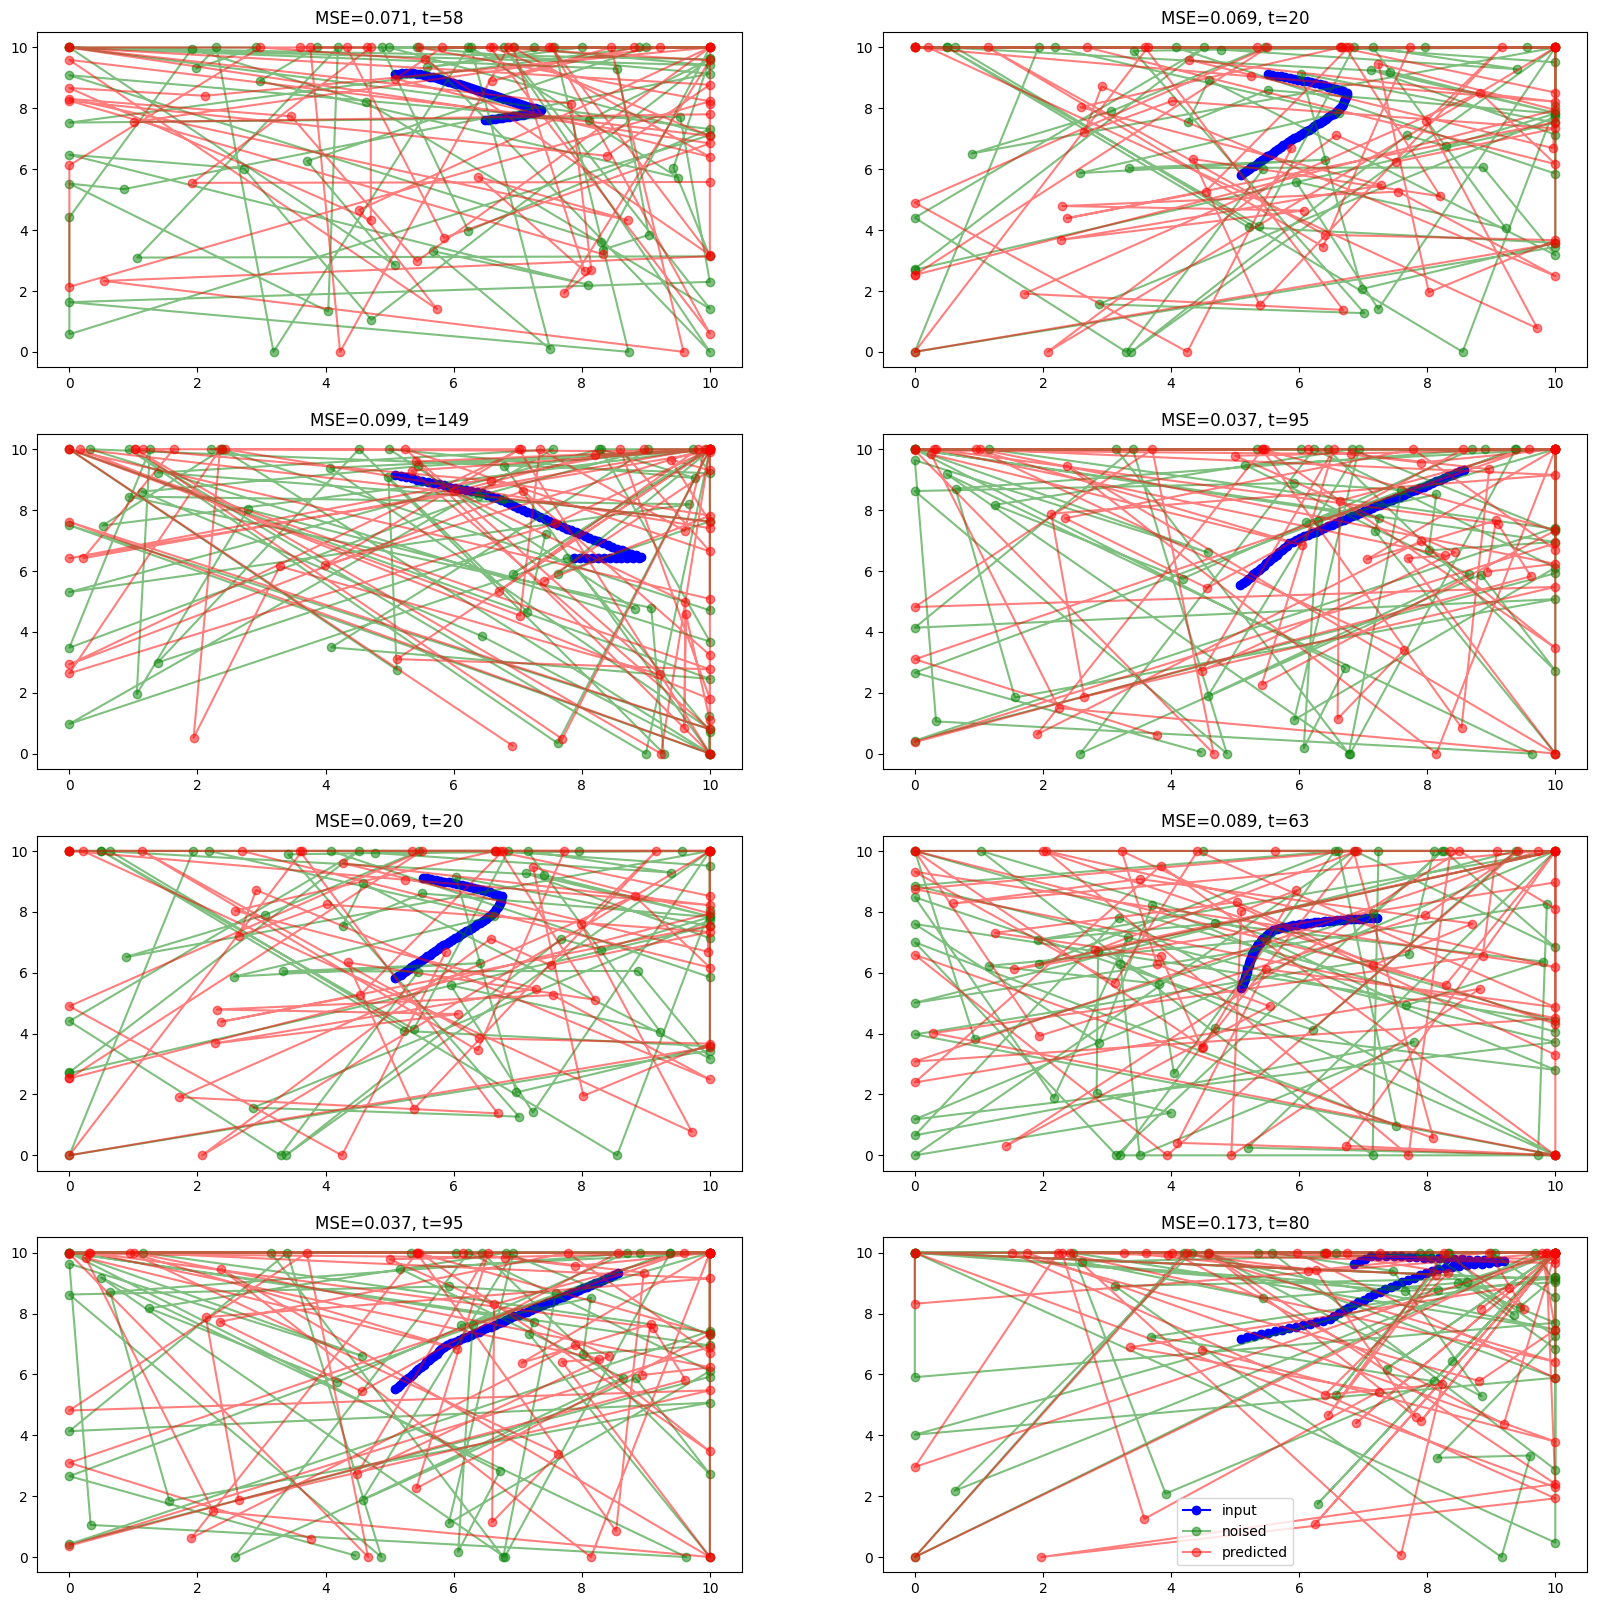

In [109]:
%%capture --no-display
trainer = pl.Trainer(max_epochs=1000, 
                     fast_dev_run=False,
                     callbacks=[VisualizeProgress(log_every_n_steps= CONFIG['visualize_every_n_steps'])], 
                     log_every_n_steps=CONFIG['stats_every_n_steps'], 
                     enable_checkpointing=True,
            );
trainer.fit(model, data);